# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 128

__deeper model__:
- hidden layers: 4
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Wider Model — Training](#4212-wider-model--training)
  - [4.2.12 Wider Model — Evaluation](#4212-wider-model--evaluation)
  - [4.2.12 Hyperparameter Search — Wider Model](#4212-hyperparameter-search--wider-model)
  - [4.2.12 Tuned Wider — Training](#4212-tuned-wider--training)
  - [4.2.12 Tuned Wider — Evaluation](#4212-tuned-wider--evaluation)

In [1]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2
from sklearn.preprocessing import OneHotEncoder

# evaluation
import datetime
from tqdm.auto import tqdm as _tqdm

# model visualization
from torchinfo import summary

# reset working dir
import os
from pathlib import Path


In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/community_area/demand_ca_6h.parquet")

In [4]:
data

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,1,residential,20,13,34.687500,877.400000,5.097500,16.110000,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01 00:00:00,482136,2,residential,4,4,30.000000,1746.750000,11.025000,32.477500,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01 00:00:00,482136,3,residential,45,42,11.896552,946.133333,5.194667,17.907111,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01 00:00:00,482136,4,residential,13,13,18.333333,628.615385,3.050000,12.468462,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01 00:00:00,482136,5,residential,12,12,23.333333,1118.583333,5.855000,21.011667,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112415,2025-12-31 18:00:00,490890,73,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.425947,3.980834,0.405491,0.135164,0.135164,0.000000,0.000000,0.000000,0.000000,0.675819
112416,2025-12-31 18:00:00,490890,74,residential,1,1,60.000000,1345.000000,7.280000,21.000000,...,3.559516,1.251690,0.000000,0.000000,0.142409,0.000000,0.000000,0.284818,0.000000,0.427226
112417,2025-12-31 18:00:00,490890,75,residential,4,4,33.750000,1362.000000,12.047500,30.742500,...,0.338770,3.515175,0.351464,0.351464,0.468619,0.000000,0.000000,0.000000,0.000000,1.171548
112418,2025-12-31 18:00:00,490890,76,airport,535,414,132.795527,2002.986916,14.461421,38.177607,...,0.296977,1.858189,0.231583,0.868438,0.578958,0.086844,0.000000,0.000000,0.028948,1.794771


## 4.2.1 Data Information

In [5]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each community area + hour-of-day combination appear?
area_hour_counts = data.groupby(['pickup_community_area', 'hour_of_day']).size()

print(f"\n--- Community area × Hour-of-day ---")
print(f"Unique area × hour combinations : {len(area_hour_counts):>8,}")
print(f"Avg appearances per combo      : {area_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {area_hour_counts.min():>8,}")
print(f"Max appearances                : {area_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :    112,420
Unique combinations (no time) :    112,420
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :  112,420 combinations

--- Community area × Hour-of-day ---
Unique area × hour combinations :      308
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :   16,725  (14.9%)
Non-zero-demand rows           :   95,695  (85.1%)


In [6]:
data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,20,13,34.687500,877.400000,5.097500,16.110000,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,4,4,30.000000,1746.750000,11.025000,32.477500,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,45,42,11.896552,946.133333,5.194667,17.907111,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,13,13,18.333333,628.615385,3.050000,12.468462,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,12,12,23.333333,1118.583333,5.855000,21.011667,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.2 Model Configurations

In [7]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "adam"
LEARNING_RATE      = 5e-5
BATCH_SIZE         = 1024
MAX_EPOCHS         = 200

# --- loss / output ---
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 128)
ARCH_DEEPER        = (4, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}


HP_SEARCH_SEEDS        = (0,)
HP_PATIENCE            = 10
BEST_HP                = {}


## 4.2.3 Model Definition

In [8]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x):
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None):
    set_seed(seed)
    n_layers, width = arch
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=_lr)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(y_train, dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t = torch.as_tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.as_tensor(y_val, dtype=torch.float32).to(device)

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        pbar = _tqdm(train_dl, leave=True, unit="step", disable=not verbose)
        for xb, yb in pbar:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
            pbar.set_postfix({"loss": f"{running_loss / n_batches:.4f}"})
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        pbar.set_postfix({"loss": f"{train_loss:.4f}", "val_loss": f"{val_loss:.4f}"})
        pbar.close()
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [9]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  device='cpu',
                  lr_candidates=None, seeds=None):
    import itertools

    lr_candidates = lr_candidates or HP_LR_CANDIDATES
    seeds         = seeds         or HP_SEARCH_SEEDS
    arch_label    = ARCH_NAMES.get(arch, str(arch))

    combos = list(itertools.product(lr_candidates))

    print(f'HP Search — {arch_label}')
    print(f'{len(combos)} combos × {len(seeds)} seed(s)'
          f' = {len(combos) * len(seeds)} runs  |  patience={HP_PATIENCE}\n')
    print(f"{{'#':>4}}  {{'lr':>8}}  {{'mean val':>10}}  {{'std':>8}}")
    print('-' * 35)

    results = []
    for i, (lr,) in enumerate(combos, 1):
        val_losses = []
        for seed in seeds:
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                seed=seed, device=device, verbose=False,
                lr=lr, patience=HP_PATIENCE,
            )
            val_losses.append(val_loss)
        mean_loss = float(np.mean(val_losses))
        std_loss  = float(np.std(val_losses))
        results.append({
            'lr': lr,
            'mean_val_loss': mean_loss, 'std_val_loss': std_loss,
        })
        print(f'{i:>4}  {lr:>8.0e}  {mean_loss:>10.4f}  {std_loss:>8.4f}')

    results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
    print(f'\n--- Top 5 ---')
    print(results_df.head(5).to_string(index=False))

    best = results_df.iloc[0]
    BEST_HP[arch] = {'lr': float(best['lr'])}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]

## Evaluation & Save Utilities
Shared helpers used after every training run below: `evaluate_models` computes the test-set metrics for the per-seed models of one architecture and returns the result rows, `save_results` appends them to the results CSV.

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
              f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"\n--- log1p scale ---")
    print(f"{label}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check (MSE, log1p scale) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_6h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌──────────────────────┬──────────────────────────────┬─────────────┐
│ pickup_community_area│  is_weekend, temp, rain, ...  │ trip_count  │
│         8            │  0,  12.3,  0.0,  ...        │      5      │
└──────────┬───────────┴───────────────┬───────────────┴──────┬──────┘
           │                           │                       │
           ▼                           ▼                       ▼
     OneHotEncoder               StandardScaler            target y
  area_8=1, rest=0           [0.0, -0.3, ...]               5.0
  (n_ca binary columns)       (n_num scaled columns)
           │                           │
           └──────────────┬────────────┘
                          ▼
                    np.concatenate
         [0, ..., 1, ..., 0,  0.0, -0.3, ...]
               (n_ca + n_num total dims)
                          │
                          ▼
              ┌─────────────────────┐
              │  Linear(dim → 64)   │
              │  ReLU               │
              │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
              │  ReLU               │
              │  Linear(64 → 1)     │
              │  Softplus           │  ← keeps output ≥ 0 (trip count)
              └─────────────────────┘
                          │
                          ▼
                   ŷ  (predicted trip count)
```

Community area identity is encoded as a one-hot vector (fit on training data only).
The network learns a separate weight for each area directly in the first linear layer.

## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [10]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :    78,694 rows
Val   :    16,863 rows
Test  :    16,863 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Community Area Encoding

Community area identity is encoded using **one-hot encoding** (fit on the training
set only). Each of the `n_ca` unique areas becomes a binary indicator column,
concatenated with the scaled numeric features before the first linear layer.

This replaces the learnable embedding used in the hexagon notebooks. With only
~77 areas the one-hot representation is compact enough to be practical, and it
has the advantage of being directly interpretable — each area gets its own
explicit weight vector in the first layer.

In [11]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# One-hot encode community area (fit on train only to avoid leakage)
ohe          = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ca_train_ohe = ohe.fit_transform(train_data[['pickup_community_area']])
ca_val_ohe   = ohe.transform(val_data[['pickup_community_area']])
ca_test_ohe  = ohe.transform(test_data[['pickup_community_area']])

scaler      = StandardScaler()
X_train_num = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val_num   = scaler.transform(val_data[FEATURE_COLS].values)
X_test_num  = scaler.transform(test_data[FEATURE_COLS].values)

X_train = np.concatenate([X_train_num, ca_train_ohe], axis=1)
X_val   = np.concatenate([X_val_num,   ca_val_ohe],   axis=1)
X_test  = np.concatenate([X_test_num,  ca_test_ohe],  axis=1)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

n_ca = ca_train_ohe.shape[1]
print(f"Community area one-hot columns : {n_ca}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

Numeric features (29): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'is_day', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'train_station_per_km2', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'universities_per_km2', 'attractions_per_km2', 'poi_density_total_per_km2']
Target scale : raw counts (count NLL)
Community area one-hot columns : 77

X_train : (78694, 106)   y_train : (78694,)
X_val   : (16863, 106)     y_val   : (16863,)
X_test  : (16863, 106)    y_test  : (16863,)


# Feature Selection

We select our features as described in the following:

1. correlation matrix
2. univariate feature testing
3. model-based feature importance

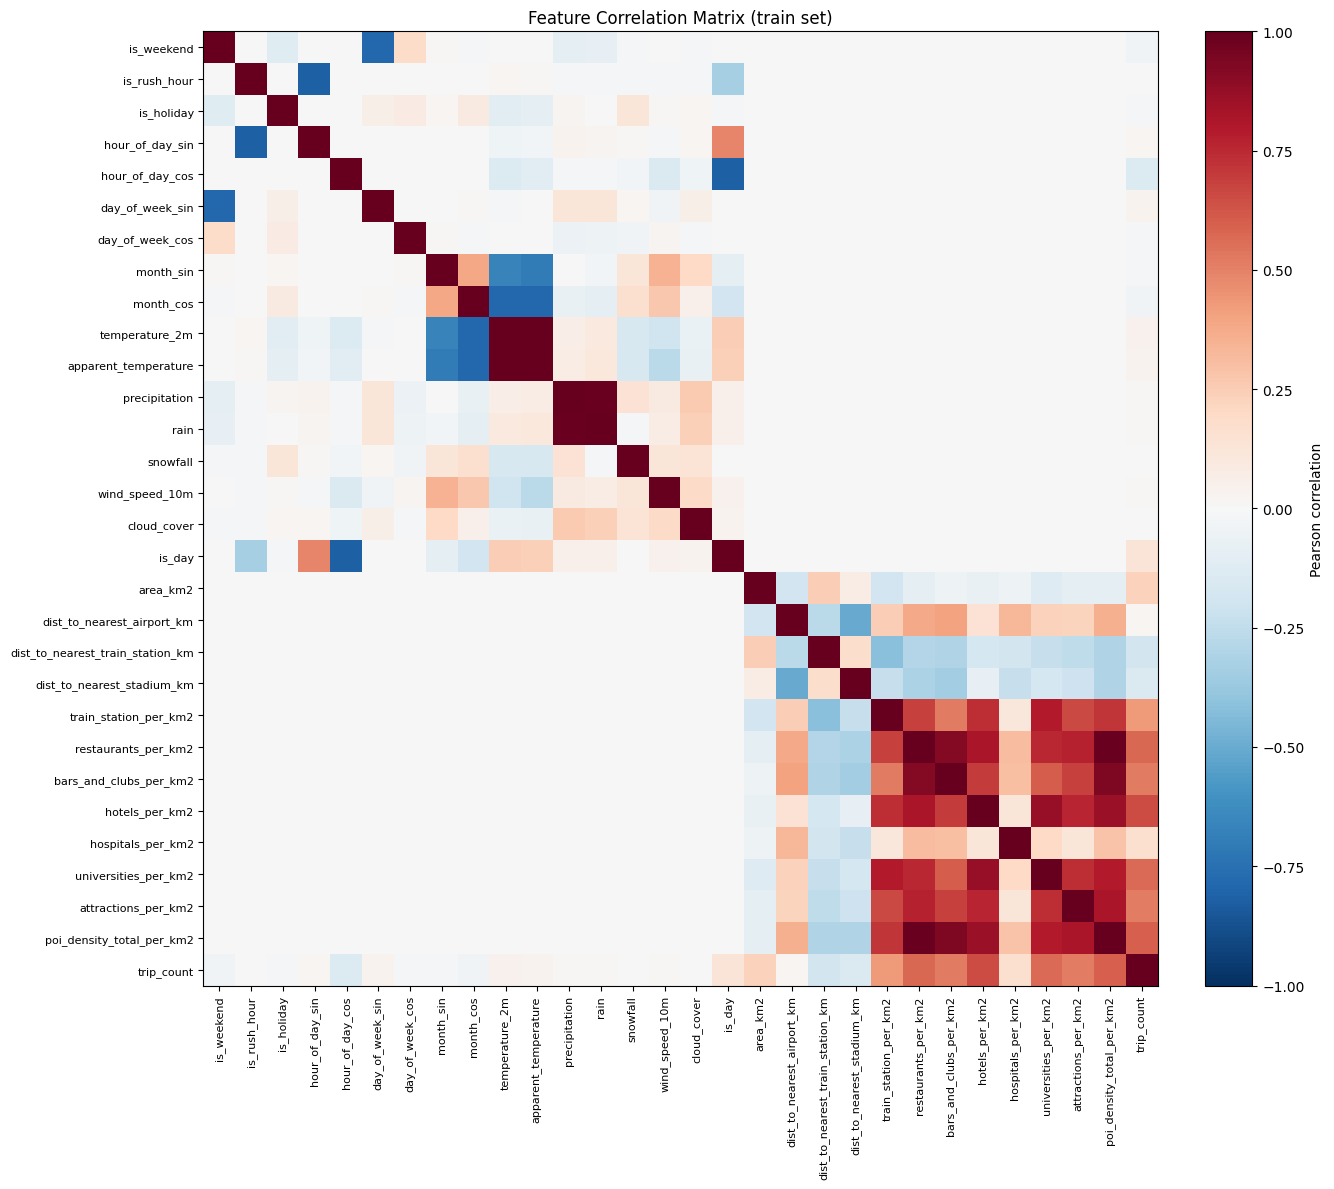

Feature pairs with |correlation| >= 0.8:
  temperature_2m                      vs apparent_temperature                 r=+0.995
  restaurants_per_km2                 vs poi_density_total_per_km2            r=+0.991
  precipitation                       vs rain                                 r=+0.986
  bars_and_clubs_per_km2              vs poi_density_total_per_km2            r=+0.930
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.921
  hotels_per_km2                      vs universities_per_km2                 r=+0.871
  hotels_per_km2                      vs poi_density_total_per_km2            r=+0.866
  restaurants_per_km2                 vs hotels_per_km2                       r=+0.820
  hour_of_day_cos                     vs is_day                               r=-0.819
  attractions_per_km2                 vs poi_density_total_per_km2            r=+0.817
  is_rush_hour                        vs hour_of_day_sin                      r=-0.816


In [12]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [13]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Univariate Tests                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.feature_selection import f_regression, mutual_info_regression

X_uni = train_data[FEATURE_COLS].values
y_uni = train_data[TARGET_COL].values

f_scores, f_pvalues = f_regression(X_uni, y_uni)
mi_scores           = mutual_info_regression(X_uni, y_uni, random_state=0)

univariate_df = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "f_score":     f_scores,
    "f_pvalue":    f_pvalues,
    "mutual_info": mi_scores,
}).sort_values("mutual_info", ascending=False).reset_index(drop=True)

print(univariate_df.to_string(index=False))

# Features with no significant univariate linear relationship (F-test)
ALPHA = 0.05
insignificant = univariate_df.loc[univariate_df["f_pvalue"] > ALPHA, "feature"].tolist()
print(f"\nFeatures with F-test p-value > {ALPHA} (no significant linear relationship with target):")
print(f"  {insignificant if insignificant else 'none'}")

                         feature      f_score      f_pvalue  mutual_info
      dist_to_nearest_airport_km    24.066261  9.326232e-07     0.744974
                        area_km2  4500.223310  0.000000e+00     0.736947
      dist_to_nearest_stadium_km  1677.916405  0.000000e+00     0.732981
       poi_density_total_per_km2 44598.558998  0.000000e+00     0.725007
dist_to_nearest_train_station_km  2742.796443  0.000000e+00     0.709957
             restaurants_per_km2 38887.560930  0.000000e+00     0.693389
           train_station_per_km2 17244.850538  0.000000e+00     0.686890
          bars_and_clubs_per_km2 29602.765182  0.000000e+00     0.675614
             attractions_per_km2 27516.711335  0.000000e+00     0.433882
                  hotels_per_km2 58778.849797  0.000000e+00     0.373192
            universities_per_km2 36516.246035  0.000000e+00     0.358653
               hospitals_per_km2  2093.627481  0.000000e+00     0.303633
                          is_day  1360.724161 2.435

In [14]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                  hotels_per_km2       0.445484         1.200271             0.011073
                          is_day       0.132865         0.227344             0.006413
                 hour_of_day_cos       0.080145         0.171198             0.003966
      dist_to_nearest_airport_km       0.089611         0.136229             0.001287
                        area_km2       0.079758         0.091131             0.001117
                 hour_of_day_sin       0.030139         0.052580             0.002270
                 day_of_week_sin       0.027250         0.047861             0.001453
      dist_to_nearest_stadium_km       0.021525         0.037130             0.000577
                      is_weekend       0.015980         0.020676             0.000589
                       month_cos       0.009198         0.015427             0.000518
                 day_of_week_cos       0.005796       

## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [15]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_community_area', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_community_area', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_community_area', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (area × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777

Historical mean (area × hour)        R²=0.8458  MAE=17.8702  RMSE=72.6765  NRMSE=1.6087
Ridge regression                     R²=0.6532  MAE=29.0346  RMSE=109.0147  NRMSE=2.4130


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [16]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width)
x_dummy   = torch.zeros(1, input_dim)
summary(viz_model, input_data=x_dummy, col_names=["input_size", "output_size", "num_params"], verbose=1)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 106]                  [1]                       1
├─Sequential: 1-1                        [1, 106]                  [1, 1]                    --
│    └─Linear: 2-1                       [1, 106]                  [1, 64]                   6,848
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 11,074
Trainable params: 11,074
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 106]                  [1]                       1
├─Sequential: 1-1                        [1, 106]                  [1, 1]                    --
│    └─Linear: 2-1                       [1, 106]                  [1, 64]                   6,848
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 11,074
Trainable params: 11,074
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.

In [17]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 21.7016  val_loss: 18.9310 ✓
Epoch   2/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 13.4258  val_loss: 11.7928 ✓
Epoch   3/200


...

  loss: 2.8077  val_loss: 2.7982 ✓
Epoch 199/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.8064  val_loss: 2.7962 ✓
Epoch 200/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.8052  val_loss: 2.7972  (no improvement 1/10)

baseline  train: 2.8064 ± 0.0000  val: 2.7962 ± 0.0000


### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [18]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0 layer weight stats:
    net.0.weight    shape=(64, 106)     max|w|=0.7199  mean|w|=0.1365  norm=14.2842
    net.2.weight    shape=(64, 64)      max|w|=0.6913  mean|w|=0.1431  norm=11.5231
    net.4.weight    shape=(1, 64)       max|w|=0.5470  mean|w|=0.1562  norm=1.5027
  seed=0  R²=0.7790  MAE=18.9034  NRMSE=1.9264  | log  R²=0.8661  MAE=0.4566  NRMSE=0.3209  | zeros 1,223/3,058  false=415  | pred min=0.0 max=2262.4

--- original scale ---
Baseline  R²    : 0.7790 ± 0.0000
Baseline  MAE   : 18.9034 ± 0.0000
Baseline  RMSE  : 87.0282 ± 0.0000
Baseline  NRMSE : 1.9264 ± 0.0000

--- log1p scale ---
Baseline  R²    : 0.8661 ± 0.0000
Baseline  MAE   : 0.4566 ± 0.0000
Baseline  RMSE  : 0.5830 ± 0.0000
Baseline  NRMSE : 0.3209 ± 0.0000

--- zero-demand ---
Baseline  Correct-zero : 1223.0 ± 0.0  (out of 3,058)
Baseline  False-zero   : 415.0 ± 0.0  (predicted 0 when demand > 0)

--

Tuned Baseline  R²=0.9313 ± 0.0020  MAE=4.4563 ± 0.0101  NRMSE=0.7787 ± 0.0113


In [19]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (25 columns)
          timestamp   loss    model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation
2026-07-13T19:54:24 nb_nll baseline         2     64        0.00005        1024     0  2.796187               3058    45.177667 0.778951 18.903396 87.028168 1.926354 0.866085 0.456601  0.583039   0.320932          1223         415  0.046529 2262.420898                   NaN              relu


## 4.2.10 Hyperparameter Search — Baseline Model

Grid search over 4 hyperparameters using the best LR from the LR search above.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_BASELINE]`.


In [20]:
# HP search candidates — Baseline (2 layers × 64 units)
# Narrow range first; widen if best LR sits at an edge
LR_CANDIDATES_BASELINE = [2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4]

In [21]:
run_hp_search(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_BASELINE,
)

HP Search — baseline
7 combos × 1 seed(s) = 7 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     2e-05      2.8867    0.0000
   2     3e-05      2.8525    0.0000
   3     4e-05      2.8227    0.0000
   4     5e-05      2.7962    0.0000
   5     6e-05      2.7725    0.0000
   6     7e-05      2.7520    0.0000
   7     1e-04      2.7055    0.0000

--- Top 5 ---
     lr  mean_val_loss  std_val_loss
0.00010       2.705496           0.0
0.00007       2.751998           0.0
0.00006       2.772489           0.0
0.00005       2.796187           0.0
0.00004       2.822686           0.0

BEST_HP[baseline] = {'lr': 0.0001}


{'lr': 0.0001}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [22]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.0001}

Epoch   1/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 17.4747  val_loss: 11.5855 ✓
Epoch   2/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 7.9989  val_loss: 6.4049 ✓
Epoch   3/200


...

  loss: 2.6536  val_loss: 2.7055 ✓
Epoch 199/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.6518  val_loss: 2.7069  (no improvement 1/10)
Epoch 200/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.6500  val_loss: 2.7107  (no improvement 2/10)

baseline  train: 2.6536 ± 0.0000  val: 2.7055 ± 0.0000


### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [23]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.7707  MAE=19.0716  NRMSE=1.9622  | log  R²=0.8698  MAE=0.4504  NRMSE=0.3164  | zeros 1,288/3,058  false=447  | pred min=0.0 max=1964.4

--- original scale ---
Tuned Baseline  R²    : 0.7707 ± 0.0000
Tuned Baseline  MAE   : 19.0716 ± 0.0000
Tuned Baseline  RMSE  : 88.6470 ± 0.0000
Tuned Baseline  NRMSE : 1.9622 ± 0.0000

--- log1p scale ---
Tuned Baseline  R²    : 0.8698 ± 0.0000
Tuned Baseline  MAE   : 0.4504 ± 0.0000
Tuned Baseline  RMSE  : 0.5749 ± 0.0000
Tuned Baseline  NRMSE : 0.3164 ± 0.0000

--- zero-demand ---
Tuned Baseline  Correct-zero : 1288.0 ± 0.0  (out of 3,058)
Tuned Baseline  False-zero   : 447.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred min : 0.0354 ± 0.0000
Baseline  Pred max : 1964.4493 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      t

In [24]:
results_df

,timestamp,loss,model,n_layers,width,learning_rate,batch_size,seed,hidden_activation,val_loss,...,rmse,nrmse,r2_log,mae_log,rmse_log,nrmse_log,correct_zero,false_zero,pred_min,pred_max
0,2026-07-13T19:54:24,nb_nll,baseline,2,64,0.00005,1024,0,relu,2.796187,...,87.028168,1.926354,0.866085,0.456601,0.583039,0.320932,1223,415,0.046529,2262.420898


In [25]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (25 columns)
          timestamp   loss          model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation
2026-07-13T20:00:41 nb_nll baseline_tuned         2     64         0.0001        1024     0  2.705496               3058    45.177667 0.770651 19.071637 88.646981 1.962186 0.869801 0.450442  0.574894   0.316449          1288         447   0.03544 1964.449341                   NaN              relu


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [26]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 9.2088  val_loss: 7.4961 ✓
Epoch   2/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 5.3091  val_loss: 5.2557 ✓
Epoch   3/200


...

  loss: 2.7727  val_loss: 2.7879 ✓
Epoch 199/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.7713  val_loss: 2.7877 ✓
Epoch 200/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.7701  val_loss: 2.7871 ✓

deep  train: 2.7701 ± 0.0000  val: 2.7871 ± 0.0000


### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [27]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test,
    device=device,
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.5520  MAE=20.4712  NRMSE=2.7425  | log  R²=0.8543  MAE=0.4743  NRMSE=0.3348  | zeros 1,197/3,058  false=396  | pred min=0.0 max=12095.5

--- original scale ---
Deep  R²    : 0.5520 ± 0.0000
Deep  MAE   : 20.4712 ± 0.0000
Deep  RMSE  : 123.8980 ± 0.0000
Deep  NRMSE : 2.7425 ± 0.0000

--- log1p scale ---
Deep  R²    : 0.8543 ± 0.0000
Deep  MAE   : 0.4743 ± 0.0000
Deep  RMSE  : 0.6081 ± 0.0000
Deep  NRMSE : 0.3348 ± 0.0000

--- zero-demand ---
Deep  Correct-zero : 1197.0 ± 0.0  (out of 3,058)
Deep  False-zero   : 396.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0292 ± 0.0000
Deep  Pred max : 12095.5371 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       2.7701    2.7871    0.3698


In [28]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (25 columns)
          timestamp   loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max  overfitting_measures hidden_activation
2026-07-13T20:01:32 nb_nll  deep         4     64        0.00005        1024     0  2.787081               3058    45.177667 0.551981 20.471188 123.897983 2.742461 0.854303 0.474304  0.608148   0.334754          1197         396  0.029215 12095.537109                   NaN              relu


## 4.2.12 Hyperparameter Search — Deeper Model

Same grid search as for the baseline, run on `ARCH_DEEPER = (4 hidden layers, 64 units)`.
Result is stored in `BEST_HP[ARCH_DEEPER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_DEEPER]`.

In [29]:
# HP search candidates — Deeper (4 layers × 64 units)
# Deeper networks often need a smaller LR to stay stable
LR_CANDIDATES_DEEPER   = [7e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3]

In [30]:
run_hp_search(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_DEEPER,
)

HP Search — deep
7 combos × 1 seed(s) = 7 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     7e-05      2.7431    0.0000
   2     1e-04      2.7032    0.0000
   3     2e-04      2.6816    0.0000
   4     3e-04      2.6861    0.0000
   5     5e-04      2.6790    0.0000
   6     7e-04      2.6797    0.0000
   7     1e-03      2.6742    0.0000

--- Top 5 ---
    lr  mean_val_loss  std_val_loss
0.0010       2.674217           0.0
0.0005       2.679016           0.0
0.0007       2.679668           0.0
0.0002       2.681567           0.0
0.0003       2.686094           0.0

BEST_HP[deep] = {'lr': 0.001}


{'lr': 0.001}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [31]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.001}

Epoch   1/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 4.0505  val_loss: 3.2666 ✓
Epoch   2/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 3.1609  val_loss: 3.0282 ✓
Epoch   3/200


...

  loss: 2.4749  val_loss: 2.6981  (no improvement 8/10)
Epoch  46/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.4686  val_loss: 2.7067  (no improvement 9/10)
Epoch  47/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.4643  val_loss: 2.6988  (no improvement 10/10)

  ↳ early stop at epoch 47  best_val=2.6742  best_train=2.5321

deep  train: 2.5321 ± 0.0000  val: 2.6742 ± 0.0000


### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [32]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.7881  MAE=18.9348  NRMSE=1.8862  | log  R²=0.8652  MAE=0.4543  NRMSE=0.3220  | zeros 1,329/3,058  false=480  | pred min=0.0 max=2376.9

--- original scale ---
Tuned Deeper  R²    : 0.7881 ± 0.0000
Tuned Deeper  MAE   : 18.9348 ± 0.0000
Tuned Deeper  RMSE  : 85.2159 ± 0.0000
Tuned Deeper  NRMSE : 1.8862 ± 0.0000

--- log1p scale ---
Tuned Deeper  R²    : 0.8652 ± 0.0000
Tuned Deeper  MAE   : 0.4543 ± 0.0000
Tuned Deeper  RMSE  : 0.5850 ± 0.0000
Tuned Deeper  NRMSE : 0.3220 ± 0.0000

--- zero-demand ---
Tuned Deeper  Correct-zero : 1329.0 ± 0.0  (out of 3,058)
Tuned Deeper  False-zero   : 480.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0268 ± 0.0000
Deep  Pred max : 2376.9431 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       2.5321   

In [33]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (25 columns)
          timestamp   loss      model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae      rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation
2026-07-13T20:04:40 nb_nll deep_tuned         4     64          0.001        1024     0  2.674217               3058    45.177667 0.788062 18.934805 85.215864 1.886239 0.86519 0.454345  0.584984   0.322003          1329         480  0.026827 2376.943115                   NaN              relu


### 4.2.12 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [34]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 35.2822  val_loss: 19.3398 ✓
Epoch   2/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 13.9105  val_loss: 9.8756 ✓
Epoch   3/200


...

  loss: 2.8036  val_loss: 2.8034 ✓
Epoch 199/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.8023  val_loss: 2.7997 ✓
Epoch 200/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.8011  val_loss: 2.7995 ✓

wide  train: 2.8011 ± 0.0000  val: 2.7995 ± 0.0000


### 4.2.12 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [35]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test,
    device=device,
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.7718  MAE=19.2291  NRMSE=1.9575  | log  R²=0.8661  MAE=0.4563  NRMSE=0.3209  | zeros 1,305/3,058  false=454  | pred min=0.0 max=2999.5

--- original scale ---
Wide  R²    : 0.7718 ± 0.0000
Wide  MAE   : 19.2291 ± 0.0000
Wide  RMSE  : 88.4335 ± 0.0000
Wide  NRMSE : 1.9575 ± 0.0000

--- log1p scale ---
Wide  R²    : 0.8661 ± 0.0000
Wide  MAE   : 0.4563 ± 0.0000
Wide  RMSE  : 0.5830 ± 0.0000
Wide  NRMSE : 0.3209 ± 0.0000

--- zero-demand ---
Wide  Correct-zero : 1305.0 ± 0.0  (out of 3,058)
Wide  False-zero   : 454.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0380 ± 0.0000
Wide  Pred max : 2999.5312 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       2.8011    2.7995    0.3398


In [36]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (25 columns)
          timestamp   loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae      rmse   nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation
2026-07-13T20:05:27 nb_nll  wide         2    128        0.00005        1024     0  2.799505               3058    45.177667 0.771755 19.229077 88.433494 1.95746 0.866125 0.456315  0.582953   0.320885          1305         454  0.038031 2999.53125                   NaN              relu


### 4.2.12 Hyperparameter Search — Wider Model

Same grid search as for the baseline, run on `ARCH_WIDER = (2 hidden layers, 128 units)`.
Result is stored in `BEST_HP[ARCH_WIDER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_WIDER]`.

In [37]:
# HP search candidates — Wider (2 layers × 128 units)
# More parameters → can tolerate slightly higher LR than deeper
LR_CANDIDATES_WIDER    = [2e-5, 3e-5, 5e-5, 7e-5, 1e-4, 2e-4, 3e-4]

In [38]:
run_hp_search(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_WIDER,
)

HP Search — wide
7 combos × 1 seed(s) = 7 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     2e-05      2.8855    0.0000
   2     3e-05      2.8540    0.0000
   3     5e-05      2.7995    0.0000
   4     7e-05      2.7561    0.0000
   5     1e-04      2.7118    0.0000
   6     2e-04      2.6756    0.0000
   7     3e-04      2.6754    0.0000

--- Top 5 ---
     lr  mean_val_loss  std_val_loss
0.00030       2.675362           0.0
0.00020       2.675649           0.0
0.00010       2.711827           0.0
0.00007       2.756086           0.0
0.00005       2.799505           0.0

BEST_HP[wide] = {'lr': 0.0003}


{'lr': 0.0003}

### 4.2.12 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [39]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.0003}

Epoch   1/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 11.1043  val_loss: 4.0231 ✓
Epoch   2/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 3.7988  val_loss: 3.6588 ✓
Epoch   3/200


...

  loss: 2.5239  val_loss: 2.6797  (no improvement 8/10)
Epoch 122/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.5203  val_loss: 2.6773  (no improvement 9/10)
Epoch 123/200


  0%|          | 0/77 [00:00<?, ?step/s]

  loss: 2.5173  val_loss: 2.6799  (no improvement 10/10)

  ↳ early stop at epoch 123  best_val=2.6754  best_train=2.5540

wide  train: 2.5540 ± 0.0000  val: 2.6754 ± 0.0000


### 4.2.12 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [40]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.7514  MAE=19.0811  NRMSE=2.0429  | log  R²=0.8708  MAE=0.4464  NRMSE=0.3153  | zeros 1,340/3,058  false=465  | pred min=0.0 max=4877.6

--- original scale ---
Tuned Wider  R²    : 0.7514 ± 0.0000
Tuned Wider  MAE   : 19.0811 ± 0.0000
Tuned Wider  RMSE  : 92.2949 ± 0.0000
Tuned Wider  NRMSE : 2.0429 ± 0.0000

--- log1p scale ---
Tuned Wider  R²    : 0.8708 ± 0.0000
Tuned Wider  MAE   : 0.4464 ± 0.0000
Tuned Wider  RMSE  : 0.5727 ± 0.0000
Tuned Wider  NRMSE : 0.3153 ± 0.0000

--- zero-demand ---
Tuned Wider  Correct-zero : 1340.0 ± 0.0  (out of 3,058)
Tuned Wider  False-zero   : 465.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0322 ± 0.0000
Wide  Pred max : 4877.5635 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       2.5540    2.6754   

In [41]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (25 columns)
          timestamp   loss       model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation
2026-07-13T21:04:17 nb_nll wider_tuned         2    128         0.0003        1024     0  2.675362               3058    45.177667 0.751387 19.081051 92.294906 2.042932 0.870771  0.44638  0.572747   0.315267          1340         465  0.032242 4877.563477                   NaN              relu


## 4.2.13 Visualization: Trip Count Distribution

Histogram of `trip_count` across the full dataset, on the raw scale, the
`log1p` scale, and the per-observation Poisson negative log-likelihood at
the empirical mean rate λ̂ — to illustrate the skew discussed above and
how well a Poisson assumption fits the data.

Empirical mean (lambda_hat) : 47.7616
Empirical variance          : 33815.4617
Dispersion (var / mean)     : 708.0056  (overdispersed)
Mean Poisson NLL @ lambda_hat: -136.8952  (up to const. log(y!))


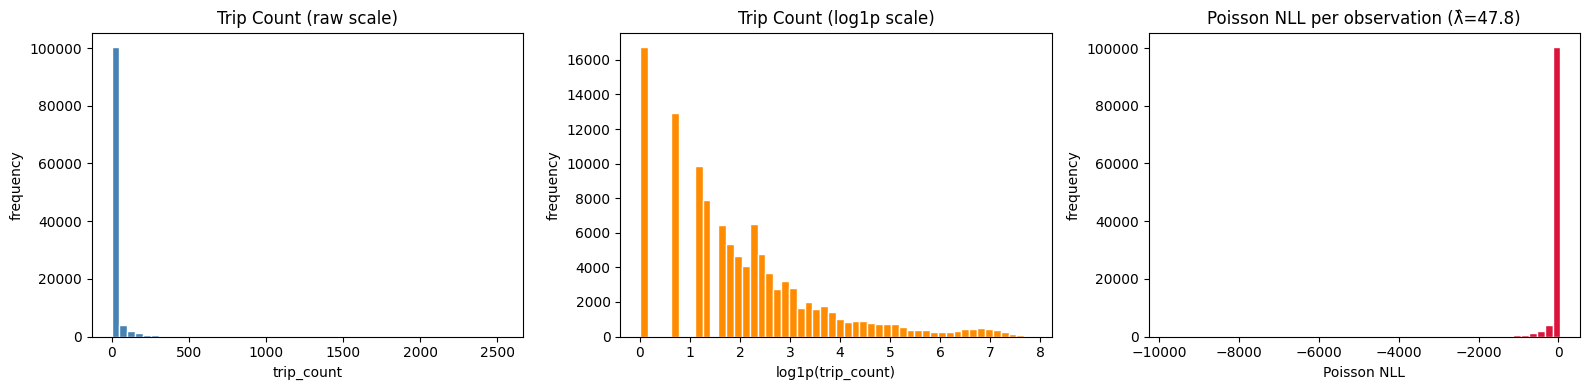

In [42]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Trip Count Distribution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

y_all       = data[TARGET_COL].values.astype(float)
lambda_hat  = y_all.mean()
dispersion  = y_all.var() / lambda_hat          # >1 indicates overdispersion vs. Poisson

# per-observation Poisson NLL at the fitted rate lambda_hat (up to the constant log(y!) term)
poisson_nll = lambda_hat - y_all * np.log(lambda_hat)

print(f"Empirical mean (lambda_hat) : {lambda_hat:.4f}")
print(f"Empirical variance          : {y_all.var():.4f}")
print(f"Dispersion (var / mean)     : {dispersion:.4f}  ({'overdispersed' if dispersion > 1 else 'underdispersed / Poisson-consistent'})")
print(f"Mean Poisson NLL @ lambda_hat: {poisson_nll.mean():.4f}  (up to const. log(y!))")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Trip Count (raw scale)")
axes[0].set_xlabel("trip_count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(y_all), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Trip Count (log1p scale)")
axes[1].set_xlabel("log1p(trip_count)")
axes[1].set_ylabel("frequency")

axes[2].hist(poisson_nll, bins=50, color="crimson", edgecolor="white")
axes[2].set_title(f"Poisson NLL per observation (λ̂={lambda_hat:.1f})")
axes[2].set_xlabel("Poisson NLL")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()